<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Module 0 · Foundations</h4>
<h1 align="center">Matplotlib Essentials</h1>
<p align="center"><i>Building static, publication-ready plots with fig, ax = plt.subplots()</i></p>

---

## About This Notebook

This is the Matplotlib section of the Module 0 refresher, split out so it can be run on its
own, in any order relative to the other Module 0 notebooks. See `00_numpy_and_pandas.ipynb`
for the NumPy/pandas fundamentals, and `02_seaborn.ipynb` / `03_plotly.ipynb` for the other
two visualization libraries.

## 0. Recreating the Dataset from Notebook 0

This notebook is meant to run on its own, in any order relative to the other Module 0
notebooks. So before we get to plotting, we rebuild the exact same synthetic "store sales"
DataFrame introduced in `00_numpy_and_pandas.ipynb`, using the same random seed (`42`), so the
data - and every chart built from it - is identical no matter which notebook you open
first.

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 300

regions = rng.choice(["North", "South", "East", "West"], size=n, p=[0.3, 0.3, 0.2, 0.2])
categories = rng.choice(["Electronics", "Grocery", "Apparel"], size=n)
units_sold = rng.poisson(lam=20, size=n)
unit_price = np.round(rng.uniform(5, 200, size=n), 2)
customer_rating = np.clip(rng.normal(loc=4.0, scale=0.7, size=n), 1, 5).round(1)

sales = pd.DataFrame({
    "region": regions,
    "category": categories,
    "units_sold": units_sold,
    "unit_price": unit_price,
    "revenue": np.round(units_sold * unit_price, 2),
    "customer_rating": customer_rating,
})

# Inject a few realistic missing values, so plots involving customer_rating have gaps to handle
missing_idx = rng.choice(sales.index, size=15, replace=False)
sales.loc[missing_idx, "customer_rating"] = np.nan

print(sales.shape)
sales.head()

(300, 6)


,region,category,units_sold,unit_price,revenue,customer_rating
0,East,Grocery,23,74.69,1717.87,3.9
1,South,Apparel,13,56.64,736.32,4.3
2,West,Apparel,24,124.04,2976.96,2.5
3,East,Electronics,21,45.05,946.05,4.0
4,North,Apparel,29,178.23,5168.67,5.0


## 1. Matplotlib Essentials

Matplotlib is the foundational plotting library in Python - Seaborn and even parts of
pandas' own `.plot()` are built directly on top of it. The pattern to internalize is
**`fig, ax = plt.subplots()`**: create a figure and an axes object explicitly, then call
plotting methods *on the axes*, rather than relying on implicit global state.

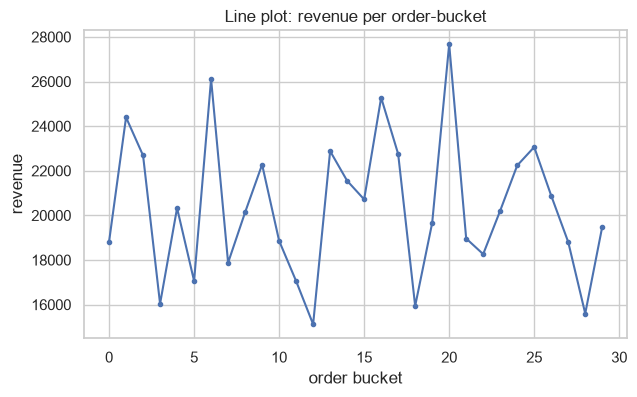

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
BLUE, RED, GREEN, ORANGE, PURPLE = "#4C72B0", "#C44E52", "#55A868", "#DD8452", "#8172B2"

fig, ax = plt.subplots(figsize=(7, 4))
daily = sales.groupby(sales.index // 10)["revenue"].sum()   # a fake "10-orders-per-day" bucket
ax.plot(daily.index, daily.values, color=BLUE, marker="o", markersize=3)
ax.set_title("Line plot: revenue per order-bucket")
ax.set_xlabel("order bucket")
ax.set_ylabel("revenue")
plt.show()

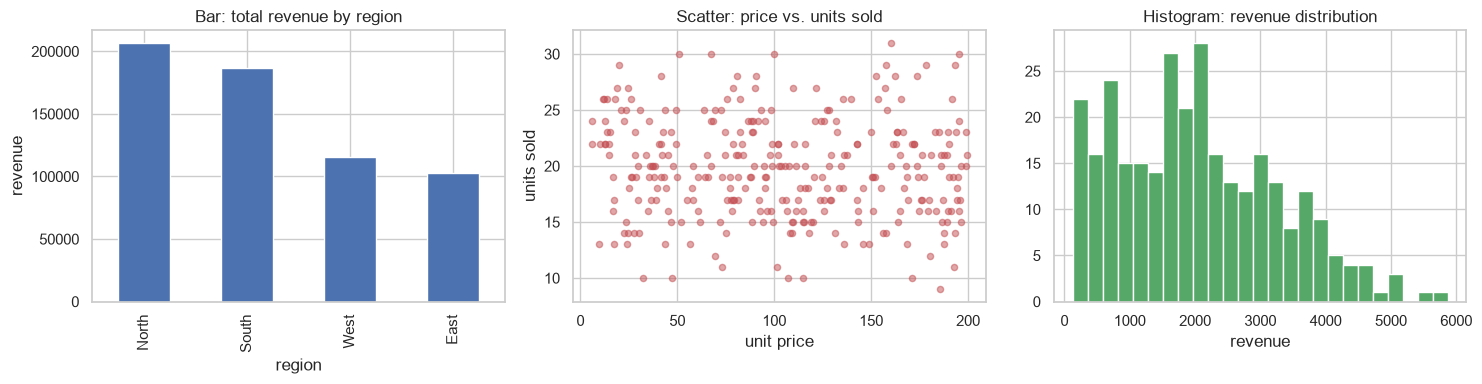

In [3]:
region_summary = sales.groupby("region").agg(
    total_revenue=("revenue", "sum"),
    avg_rating=("customer_rating", "mean"),
    n_orders=("revenue", "count"),
).sort_values("total_revenue", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bar plot
region_summary["total_revenue"].plot(kind="bar", ax=axes[0], color=BLUE)
axes[0].set_title("Bar: total revenue by region")
axes[0].set_ylabel("revenue")

# Scatter plot
axes[1].scatter(sales["unit_price"], sales["units_sold"], color=RED, alpha=0.5, s=20)
axes[1].set_title("Scatter: price vs. units sold")
axes[1].set_xlabel("unit price")
axes[1].set_ylabel("units sold")

# Histogram
axes[2].hist(sales["revenue"], bins=25, color=GREEN, edgecolor="white")
axes[2].set_title("Histogram: revenue distribution")
axes[2].set_xlabel("revenue")

plt.tight_layout()
plt.show()

**What this tells us:** all three panels above came from the same `fig, axes = plt.subplots(1, 3, ...)`
call - one figure, a 1x3 grid of axes, each customized independently. This multi-panel
pattern (`subplots(rows, cols)` + a loop or manual indexing over `axes`) is the single most
reused Matplotlib idiom in the topic notebooks that follow. Titles, axis labels, legends, and
`figsize` are the basic styling knobs you'll reach for constantly.

## 2. Which Tool, When?

The original Module 0 decision guide is split across this folder's four notebooks, one entry
per notebook. Here is the entry for Matplotlib:

- **Matplotlib** - full manual control over every pixel of a static figure; the right choice
  for a polished, publication- or report-ready image, and the substrate both Seaborn and
  pandas' `.plot()` are built on.

See `00_numpy_and_pandas.ipynb`, `02_seaborn.ipynb`, and `03_plotly.ipynb` for the other
entries.

## Summary

- Rebuilt the same synthetic "store sales" dataset used across every Module 0 notebook.
- **Matplotlib**: the `fig, ax = plt.subplots()` pattern, line/bar/scatter/histogram plots,
  multi-panel figures, and basic styling.
- When Matplotlib is the right call vs. reaching for Seaborn or Plotly instead.

See `00_numpy_and_pandas.ipynb`, `02_seaborn.ipynb`, and `03_plotly.ipynb` for the rest of
the Module 0 refresher.